# Deep Pool-based Active Learning: Scikit-activeml with Skorch

> **_Google Colab Note:_** If the notebook fails to run after installing the needed packages, try to restart the runtime (Ctrl + M) under Runtime -> Restart session.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](<colab_link>)

**Notebook Dependencies**

<div class="alert alert-block alert-info">
  <strong>Disclaimer:</strong> This notebook is currently not compatible with <code>skactiveml=0.6.0</code>. As of now, <code>skorch=1.1.0</code> does not fully support <code>torch_load_kwargs</code>. Therefore, we resort to installing <code>skorch</code> from source.
</div>


Uncomment the following cell to install all dependencies for this tutorial.

In [1]:
# !pip install scikit-activeml skorch torch torchvision torchaudio tqdm pandas
# !pip install --upgrade git+https://github.com/skorch-dev/skorch.git

<hr style="border-style: solid; border-top: 1px solid; border-right: 0; border-bottom: 0; border-left: 0;">

In this brief tutorial, we show an example use-case of our package `skactiveml` with the Python package [skorch](https://skorch.readthedocs.io/en/stable/), which is a scikit-learn wrapper for Pytorch models. This way, we are able to implement and test deep learning models in combination with query strategies implemented in our framework.

In [2]:
import matplotlib as mlp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import warnings

from copy import deepcopy

from skactiveml.classifier import SkorchClassifier
from skactiveml.pool import RandomSampling, UncertaintySampling, Badge, DropQuery, SubSamplingWrapper
from skactiveml.utils import call_func

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from skorch.callbacks import LRScheduler

from torch import nn
from torch.optim import RAdam
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision.transforms import transforms

from tqdm import tqdm

mlp.rcParams["figure.facecolor"] = "white"

MISSING_LABEL = -1
RANDOM_STATE = 0
FONTSIZE = 12

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

warnings.filterwarnings("ignore")

## Loading Digit Data Set
For simplicity, we use the `sklearn` function `fetch_openml` to load the MNIST dataset. The dataset contains 28 x 28px images of handwritten digits from 0 to 9 and the task is to recognize the digits in the images.

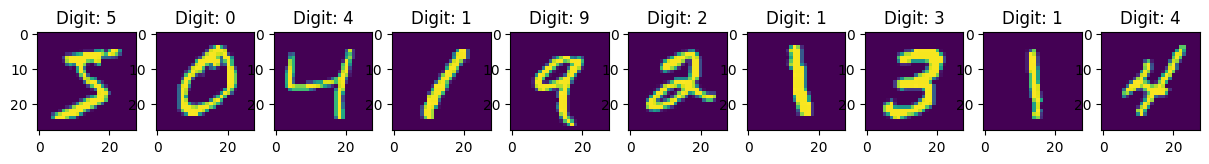

In [3]:
# Load digit data set.
X, y_true = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

# Visualize first 10 images.
fig, axes = plt.subplots(figsize=(15, 5), nrows=1, ncols=10)
for i in range(10):
    axes[i].set_title(f'Digit: {y_true[i]}', fontsize=FONTSIZE)
    axes[i].imshow(X[i].reshape(28,28))
plt.show()

# Reshape samples to n_samples x n_channels x width x height to fit skorch
# requirements.
X = X.reshape((len(X), 1, 28, 28)) / 255

# Set data types according to skorch requirements.
X, y_true = X.astype(np.float32), y_true.astype(np.int64)

# Identify list of possible classes.
classes = np.unique(y_true)

# Make a 66-34 train-test split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_true, train_size=0.66, random_state=RANDOM_STATE
)

## Data Augmentation
Data augmentation is used to artificially generate data from existing data points. In case of image data, this can be done by rotating or scaling the image. Other basic transformations are:
* padding,
* vertical and horizontal flipping,
* translation,
* cropping,
* darkening, brightening, color modification,
* grayscaling,
* changing contrast,
* adding noise,
* random erasing.

For more information on data augmentation take a look at the [Data Augmentation Tutorial](https://www.tensorflow.org/tutorials/images/data_augmentation) of [TensorFlow](https://www.tensorflow.org) or visit [Transforming And Augmenting Images](https://pytorch.org/vision/stable/transforms.html) on [PyTorch](https://pytorch.org).

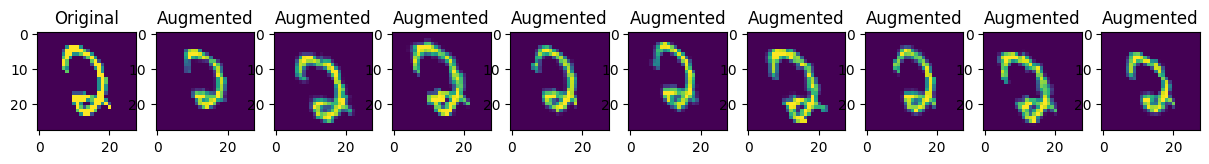

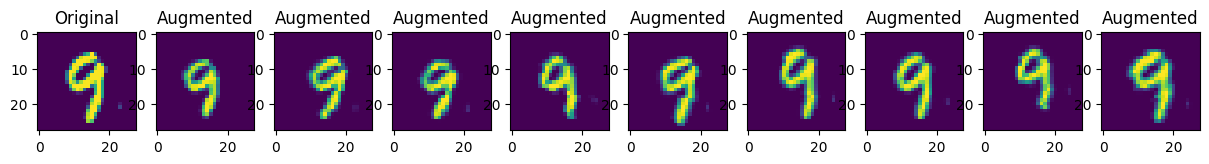

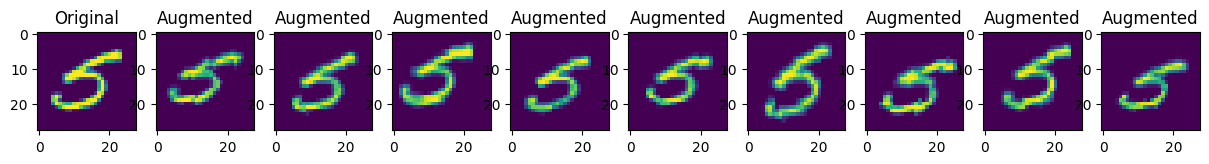

In [4]:
train_transform = transforms.Compose(
    [
        transforms.RandomAffine(degrees=(-10, 10), translate=(0.05, 0.05), scale=(0.9, 1.1)),
        transforms.RandomPerspective(distortion_scale=0.2, p=1.0),
        transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.01, 0.1)),
        transforms.Normalize(mean=(0.1307,), std=(0.3081,))
    ]
)

eval_transform = transforms.Compose([
    transforms.Normalize(mean=(0.1307,), std=(0.3081,))
])


# Visualize 30 augmented images.
for i in range(3):
    fig, axes = plt.subplots(figsize=(15, 5), nrows=1, ncols=10)
    for j in range(10):
        if j==0:
            axes[j].set_title(f'Original', fontsize=FONTSIZE)
            axes[j].imshow(X_train[i].reshape(28,28))
        else:
            axes[j].set_title(f'Augmented', fontsize=FONTSIZE)
            axes[j].imshow(train_transform(torch.from_numpy(X_train[i])).reshape(28,28))
    plt.show()

## Convolutional Neural Network Classifier
In the next step, we define a convolutional neural network (CNN) classifier with a basic architecture for illustration purposes.

> **Note:** There is an interdependency between the
> - loss criterion (`nn.CrossEntropyLoss` in our example),
> - the outputted quantities (logits in our example),
> - and calling `predict_proba` to output actual probabilities (`predict_nonlinearity=nn.Softmax(dim=-1)` to normalize the logits).

In [5]:
# Define simple CNN as PyTorch module.
class ClassifierModule(nn.Module):
    def __init__(self, n_classes, dropout=0.5, train_transform=None, eval_transform=None):
        super(ClassifierModule, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv2_drop = nn.Dropout2d(p=dropout)
        self.fc1 = nn.Linear(1600, 100)
        self.fc2 = nn.Linear(100, n_classes)
        self.fc1_drop = nn.Dropout(p=dropout)
        self.train_transform = train_transform
        self.eval_transform = eval_transform

    def forward(self, x):
        # Workaround because usually transforms are part of the datasets.
        if self.training and self.train_transform:
            with torch.no_grad():
                x = self.train_transform(x)
        if not self.training and self.eval_transform:
            with torch.no_grad():
                x = self.eval_transform(x)
        x = torch.relu(F.max_pool2d(self.conv1(x), 2))
        x = torch.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))

        # Flatten over channel, height and width = 1600.
        x = x.view(x.size(0), -1)
        x_embed = self.fc1(x)

        x = torch.relu(self.fc1_drop(x_embed))
        x = self.fc2(x)
        return x, x_embed

clf_init = SkorchClassifier(
    module=ClassifierModule,
    criterion=nn.CrossEntropyLoss,
    neural_net_param_dict={
        "module__n_classes": len(classes),
        "module__train_transform": train_transform,
        "module__eval_transform": eval_transform,
        "max_epochs": 100,
        "batch_size": 128,
        "lr": 0.01,
        "verbose": 0,
        "optimizer": RAdam,
        "optimizer__weight_decay": 3e-3,
        "train_split": False,
        "device": device,
        "predict_nonlinearity": nn.Softmax(dim=-1),
        "torch_load_kwargs": {'weights_only': True},
        "callbacks": [('lr_scheduler', LRScheduler(policy=CosineAnnealingLR, T_max=100))],
    },
    classes=classes,
    missing_label=MISSING_LABEL,
)

## Active Classification
For our ensemble, we evaluate four different query strategies, i.e., random sampling, uncertainty sampling, query-by-committee, and batch BALD, regarding their sample selection. For this purpose, we start with zero labels and make 15 iterations of an active learning cycle with a batch size of 32.

> **Note:** The execution time strongly depends on whether a GPU or CPU will be used. For example, the below reported times will be much faster when using an advanced GPU.

In [6]:
# Define setup.
n_cycles = 10
batch_size = 32
n_sub_set = 1000
qs_dict = {
    'Random': RandomSampling(random_state=RANDOM_STATE, missing_label=MISSING_LABEL),
    'US': UncertaintySampling(random_state=RANDOM_STATE, missing_label=MISSING_LABEL),
    'BADGE': Badge(clf_embedding_flag_name="return_embeddings", random_state=RANDOM_STATE, missing_label=MISSING_LABEL),
    'DropQuery': DropQuery(clf_embedding_flag_name="return_embeddings", random_state=RANDOM_STATE, missing_label=MISSING_LABEL),
}
acc_dict = {key: np.zeros(n_cycles + 1) for key in qs_dict}

# Perform active learning with each query strategy.
for qs_name, qs in qs_dict.items():
    print(f'Execute active learning using {qs_name}.')
    # Wrapper to subsample unlabeled samples.
    qs = SubSamplingWrapper(
        query_strategy=qs,
        max_candidates=1000,
        exclude_non_subsample=True,
        random_state=RANDOM_STATE,
        missing_label=MISSING_LABEL
    )

    # Set seed and copy classifier for consistent initialization.
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed(RANDOM_STATE)
    clf = deepcopy(clf_init)

    # Create array of missing labels as initial labels.
    X = X_train
    y = np.full_like(y_train, fill_value=MISSING_LABEL, dtype=np.int64)

    # Execute active learning cycle.
    for c in tqdm(range(n_cycles)):
        # Fit and evaluate clf.
        acc = clf.fit(X, y).score(X_test, y_test)
        acc_dict[qs_name][c] = acc

        # Select and update training data.
        query_idx = call_func(
            qs.query,
            X=X,
            y=y,
            clf=clf,
            fit_clf=False,
            batch_size=batch_size,
        )
        y[query_idx] = y_train[query_idx]

    # Fit and evaluate clf.
    clf.fit(X, y)
    acc_dict[qs_name][n_cycles] = clf.score(X_test, y_test)

Execute active learning using Random.


100%|██████████| 10/10 [01:42<00:00, 10.30s/it]


Execute active learning using US.


100%|██████████| 10/10 [01:41<00:00, 10.12s/it]


Execute active learning using BADGE.


100%|██████████| 10/10 [02:04<00:00, 12.46s/it]


Execute active learning using DropQuery.


100%|██████████| 10/10 [02:59<00:00, 17.93s/it]


## Visualize Results
In the following, we plot the obtained learning curves including the area under learning curve (AULC) scores per query strategy.

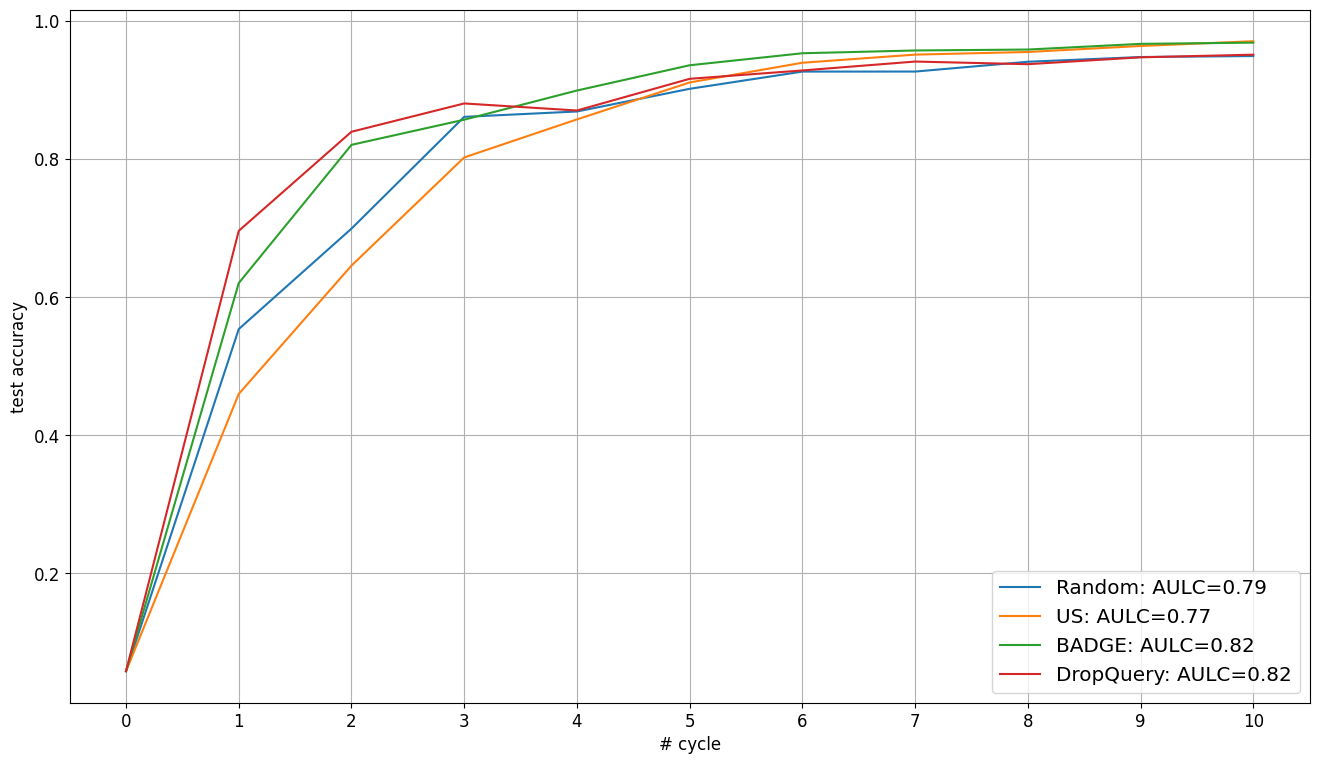

In [7]:
cycles = np.arange(n_cycles + 1, dtype=int)
plt.figure(figsize=(16, 9))
for qs_name, acc in acc_dict.items():
    plt.plot(cycles, acc, label=f'{qs_name}: AULC={round(acc.mean(), 2)}')
plt.xticks(cycles, fontsize=FONTSIZE)
plt.yticks(fontsize=FONTSIZE)
plt.grid()
plt.xlabel('# cycle', fontsize=FONTSIZE)
plt.ylabel('test accuracy', fontsize=FONTSIZE)
plt.legend(loc='lower right', fontsize='x-large')
plt.show()